<a href="https://colab.research.google.com/github/barry-clarke/CS5004/blob/main/Etivity3_24325082_Tasks1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Averaging over 50 runs to smooth the data. This might take a few seconds...


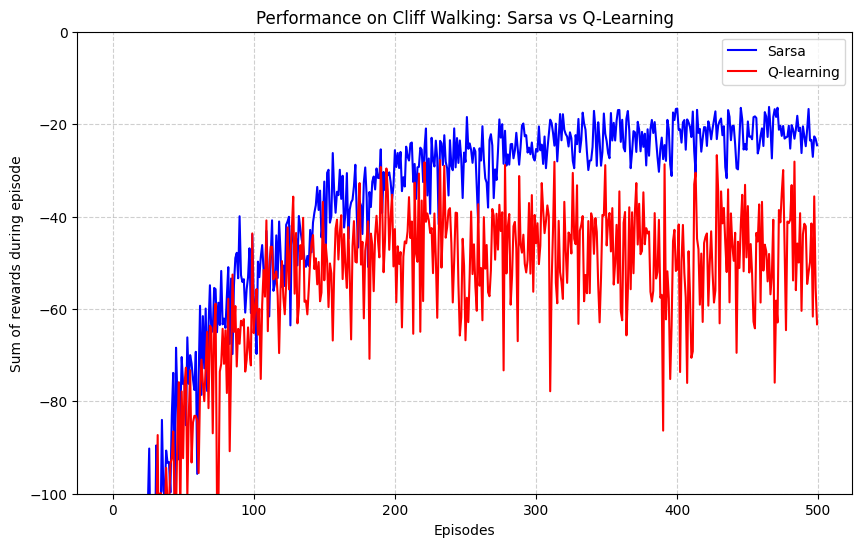

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# --- 1. Environment Setup ---
# The grid is 4 rows by 12 columns.
GRID_HEIGHT = 4
GRID_WIDTH = 12
START = (3, 0)
GOAL = (3, 11)

# Actions: 0: UP, 1: RIGHT, 2: DOWN, 3: LEFT
ACTIONS = [0, 1, 2, 3]

def step(state, action):
    """Takes a state and action, returns the next state and reward."""
    i, j = state
    if action == 0:   # UP
        i = max(i - 1, 0)
    elif action == 1: # RIGHT
        j = min(j + 1, GRID_WIDTH - 1)
    elif action == 2: # DOWN
        i = min(i + 1, GRID_HEIGHT - 1)
    elif action == 3: # LEFT
        j = max(j - 1, 0)

    next_state = (i, j)

    # Check for the Cliff: bottom row, columns 1 to 10
    if i == 3 and 1 <= j <= 10:
        return START, -100 # Fall off cliff, heavy penalty, return to start

    # Check for Goal
    if next_state == GOAL:
        return next_state, 0 # Reached goal

    # Normal step
    return next_state, -1

# --- 2. Action Selection (Epsilon-Greedy) ---
def choose_action(state, q_table, epsilon):
    """Returns an action using epsilon-greedy policy."""
    if random.uniform(0, 1) < epsilon:
        return random.choice(ACTIONS)
    else:
        # Exploit: choose action with max Q-value
        # np.random.choice breaks ties randomly
        max_q = np.max(q_table[state[0], state[1]])
        best_actions = [a for a in ACTIONS if q_table[state[0], state[1], a] == max_q]
        return random.choice(best_actions)

# --- 3. The Agents ---
def run_q_learning(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):
    """Runs the off-policy Q-Learning algorithm."""
    # Initialise Q(s, a) arbitrarily (zeros), terminal state will remain 0
    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        while state != GOAL:
            # a. Select action using epsilon-greedy
            action = choose_action(state, q_table, epsilon)

            # b. Take action, observe reward and next state
            next_state, reward = step(state, action)
            total_reward += reward

            # c. Update Q-value using max over next actions (Off-Policy)
            best_next_q = np.max(q_table[next_state[0], next_state[1]])
            td_target = reward + gamma * best_next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            # d. Update state
            state = next_state

        rewards_per_episode.append(total_reward)
    return rewards_per_episode

def run_sarsa(episodes, alpha=0.1, gamma=1.0, epsilon=0.1):
    """Runs the on-policy Sarsa algorithm."""
    # Initialise Q(s, a) arbitrarily (zeros), terminal state will remain 0
    q_table = np.zeros((GRID_HEIGHT, GRID_WIDTH, len(ACTIONS)))
    rewards_per_episode = []

    for _ in range(episodes):
        state = START
        total_reward = 0

        # Select initial action using epsilon-greedy
        action = choose_action(state, q_table, epsilon)

        while state != GOAL:
            # a. Take action, observe reward and next state
            next_state, reward = step(state, action)
            total_reward += reward

            # b. Select next action from next state using epsilon-greedy
            next_action = choose_action(next_state, q_table, epsilon)

            # c. Update Q-value using the specific next action chosen (On-Policy)
            next_q = q_table[next_state[0], next_state[1], next_action]
            td_target = reward + gamma * next_q
            td_error = td_target - q_table[state[0], state[1], action]
            q_table[state[0], state[1], action] += alpha * td_error

            # d. Update state and action
            state = next_state
            action = next_action

        rewards_per_episode.append(total_reward)
    return rewards_per_episode

# --- 4. Running the Experiment ---
EPISODES = 500
RUNS = 50 # Run multiple times to average the results and smooth the graph

q_rewards = np.zeros(EPISODES)
sarsa_rewards = np.zeros(EPISODES)

print(f"Averaging over {RUNS} runs to smooth the data. This might take a few seconds...")

for i in range(RUNS):
    q_rewards += run_q_learning(EPISODES)
    sarsa_rewards += run_sarsa(EPISODES)

# Average the rewards
q_rewards /= RUNS
sarsa_rewards /= RUNS

# --- 5. Plotting the Results ---
plt.figure(figsize=(10, 6))
plt.plot(sarsa_rewards, label='Sarsa', color='blue', linewidth=1.5)
plt.plot(q_rewards, label='Q-learning', color='red', linewidth=1.5)
plt.xlabel('Episodes')
plt.ylabel('Sum of rewards during episode')
plt.title('Performance on Cliff Walking: Sarsa vs Q-Learning')
plt.ylim(-100, 0) # Matching the limits from the textbook
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()